## Exercise Interpolation

In [1]:
%matplotlib inline
import math
import numpy as np
from matplotlib import pyplot as plt

1) Plot these four points (2,3), (3,1), (4,2), (5,2).

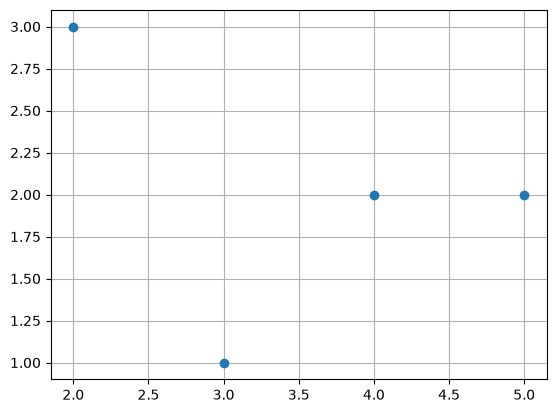

In [2]:
xs = np.array([2, 3, 4, 5])
ys = np.array([3, 1, 2, 2])
plt.plot(xs, ys, 'o', label='Data Points')
plt.grid()

2) Find the polynomial of degree 3 that pass through these four points. Plot to verify.

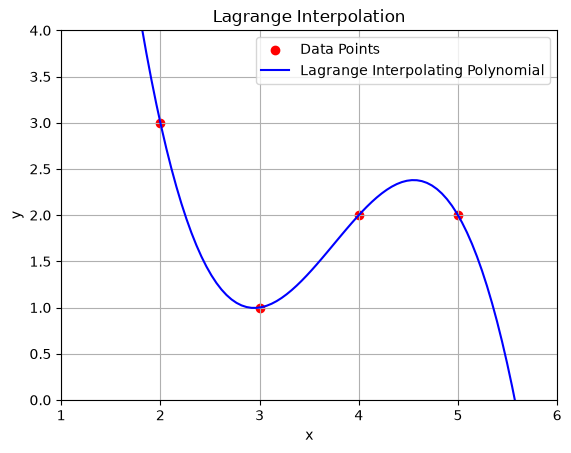

In [3]:
def diff_fn(x_n):
    def make_diff(x):
        return x - x_n
    return make_diff

#print(diff_fn(2)(5))  # should be 3

def p(n, x):
    product = 1
    for i, x_n in enumerate(xs):
        if n != i:
            product *= diff_fn(x_n)(x)
    return product

def L(n, x):
    return p(n, x) / p(n, xs[n])

def lagrange(x):
    total = 0
    for n, y_n in enumerate(ys):
        total += y_n * L(n, x)
    return total

x_dense = np.linspace(1, 6, 100)
y_dense = lagrange(x_dense)

plt.scatter(xs, ys, label='Data Points', color='red')
plt.plot(x_dense, y_dense, label='Lagrange Interpolating Polynomial', color='blue')
plt.xlim(1, 6)
plt.ylim(0, 4)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Lagrange Interpolation')
plt.legend()
plt.grid(True)
plt.show()

3) Find polynomial of degree 3 that pass through these four points. Plot to verify.

(1,2) (2,0) (3,2) (7,1)

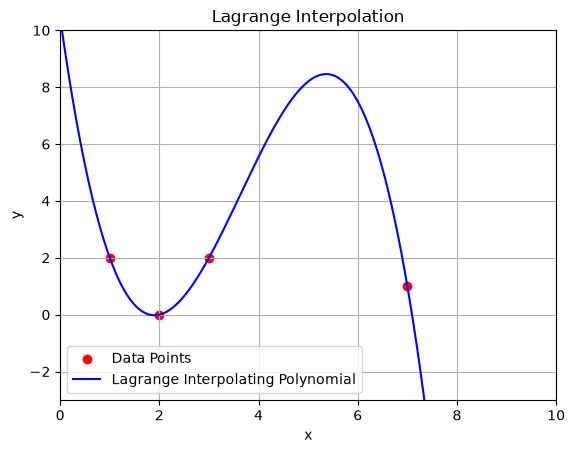

In [4]:
xs = np.array([1, 2, 3, 7])
ys = np.array([2, 0, 2, 1])
x_dense = np.linspace(min(xs)-1, max(xs)+1, 200)
y_dense = lagrange(x_dense)

plt.scatter(xs, ys, label='Data Points', color='red')
plt.plot(x_dense, y_dense, label='Lagrange Interpolating Polynomial', color='blue')
plt.xlim(0, 10)
plt.ylim(-3, 10)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Lagrange Interpolation')
plt.legend()
plt.grid(True)
plt.show()

4) Write a function `lagrange(x)` which compute the lagrange polynomial given the list of x values in xs and y values in ys.

`lagrange(1.5)`

should have the same value as the polymial you found in 3) evaluated at x=1.5.

For those of you who know functional programming try write a functor that return a polynomial.

In [5]:
def lagrange_interpolate(x_data, y_data, x):
    n = len(x_data)
    result = 0.0

    for i in range(n):
        # Construct L_i(x)
        L_i = 1.0

        for j in range(n):
            if j != i:
                L_i *= (x - x_data[j]) / (x_data[i] - x_data[j])

        # Add y_i L_i(x)
        result += y_data[i] * L_i

    return result

In [6]:
lagrange_interpolate([1, 2, 3, 7], [2, 0, 2, 1], 1.5)

0.346875

In [7]:
print(lagrange(1.5))

0.346875


### Functional programming approach

`make_lagrange(x_data, y_data)` is a higher-order function: it returns a function representing the interpolating polynomial. The returned function is a **closure** that remembers the supplied nodes and values, so you can evaluate it repeatedly with just `x`.

`prod` builds each Lagrange basis term, and `sum` combines the weighted terms without updating an accumulator. As with the original formula, the input lists must have equal length and the x-values must be distinct.

In [8]:
from math import prod

def make_lagrange(x_data, y_data):
    x_nodes, y_nodes = tuple(x_data), tuple(y_data)

    def polynomial(x):
        return sum(
            y_i * prod(
                (x - x_j) / (x_nodes[i] - x_j)
                for j, x_j in enumerate(x_nodes) if j != i
            )
            for i, y_i in enumerate(y_nodes)
        )

    return polynomial


lagrange_functional = make_lagrange([1, 2, 3, 7], [2, 0, 2, 1])
print(lagrange_functional(1.5))

0.346875


5) Now sample 11 points  from $f(x) = \sin(x)$ for for $x\in[0, \pi]$. Plot $\sin(x)$ along with those 11 points. Make sure your $\sin(x)$ is plotted with more than 100 points

In [9]:
def f(x) -> float:
    return np.sin(x)

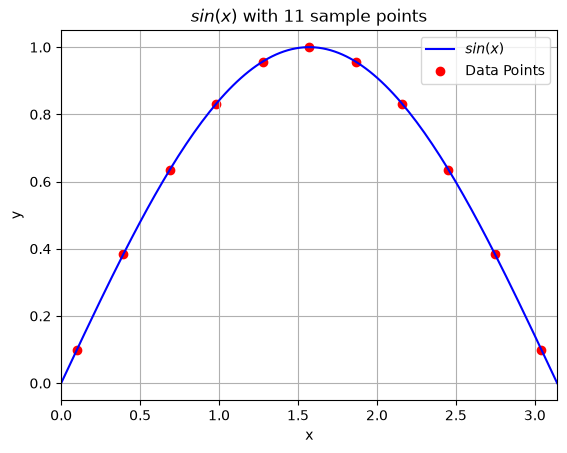

In [10]:
x = np.linspace(0, np.pi, 1<<7)
y = f(x)

dp_x = np.linspace(0+0.1, np.pi-0.1, 11)
dp_y = f(dp_x)

plt.plot(x, y, label='$sin(x)$', color='blue')
plt.scatter(dp_x, dp_y, label='Data Points', color='red')
plt.xlim(0, np.pi)
plt.xlabel('x')
plt.ylabel('y')
plt.title('$sin(x)$ with 11 sample points')
plt.legend()
plt.grid(True)
plt.show()

6) Plot lagrange polynomial for these points. How similar is it to $\sin(x)$ function. Make sure your lagrange is plotte with at least 100 points.

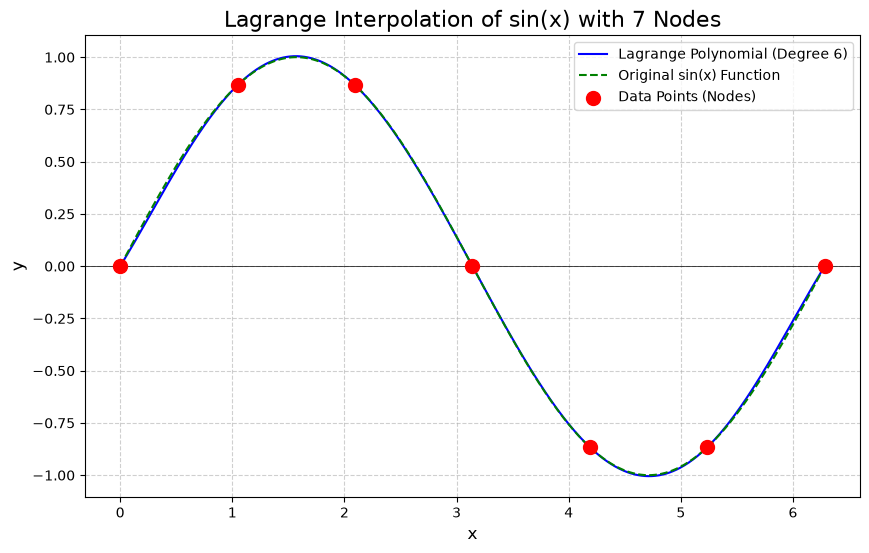

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 0. Another example of implementation of Lagrange polynomial interpolation
def lagrange_polynomial(x_nodes, y_nodes, x_eval):
    """
    Manually calculates the value of a Lagrange interpolating polynomial at a given point.
    """
    n = len(x_nodes)
    polynomial_result = 0.0

    for i in range(n):
        basis_poly_i = 1.0
        for j in range(n):
            if i != j:
                basis_poly_i *= (x_eval - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
        polynomial_result += y_nodes[i] * basis_poly_i

    return polynomial_result

# 1. Define the exact nodes you requested
x_nodes = np.linspace(0, 2 * np.pi, 7)
y_nodes = np.sin(x_nodes)

# 2. Create a dense range of x-values for plotting a smooth curve
x_dense = np.linspace(0, 2 * np.pi, 1000)

# 3. Calculate the polynomial's y-values for the dense x-range
y_dense = [lagrange_polynomial(x_nodes, y_nodes, x) for x in x_dense]

# 4. Plot the results
plt.figure(figsize=(10, 6))
# Plot the smooth Lagrange polynomial
plt.plot(x_dense, y_dense, label='Lagrange Polynomial (Degree 6)', color='blue')
# Plot the original sine wave for comparison
plt.plot(x_dense, np.sin(x_dense), label='Original sin(x) Function', color='green', linestyle='--')
# Plot the 7 nodes the polynomial must pass through
plt.scatter(x_nodes, y_nodes, color='red', s=100, zorder=5, label='Data Points (Nodes)')

plt.title('Lagrange Interpolation of sin(x) with 7 Nodes', fontsize=16)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=0.5)
plt.show()

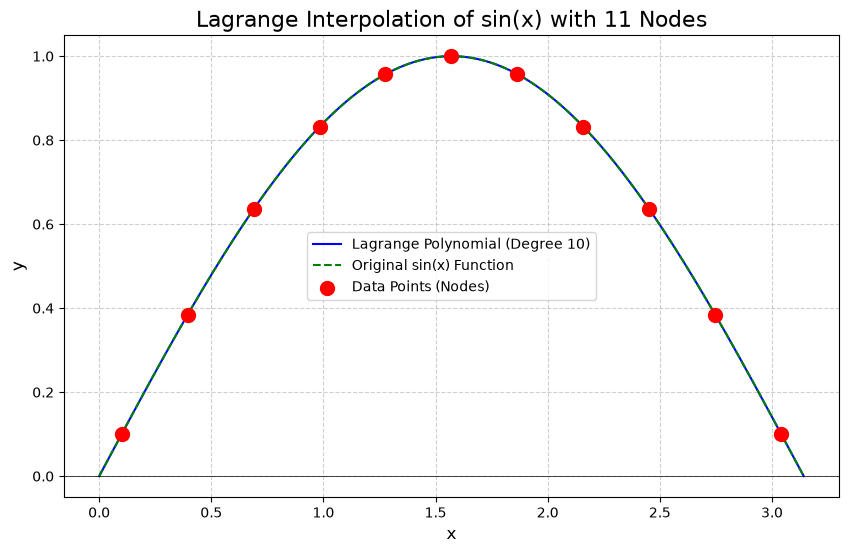

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 0. Another example of implementation of Lagrange polynomial interpolation
"""
def lagrange_polynomial(x_nodes, y_nodes, x_eval):

    # Manually calculates the value of a Lagrange interpolating polynomial at a given point.
    
    n = len(x_nodes)
    polynomial_result = 0.0

    for i in range(n):
        basis_poly_i = 1.0
        for j in range(n):
            if i != j:
                basis_poly_i *= (x_eval - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
        polynomial_result += y_nodes[i] * basis_poly_i

    return polynomial_result
"""

# 1. Define the exact nodes you requested
x_nodes = np.linspace(0+0.1, np.pi-0.1, 11)
y_nodes = f(dp_x)

# 2. Create a dense range of x-values for plotting a smooth curve
x_dense = np.linspace(0, np.pi, 1<<10)

# 3. Calculate the polynomial's y-values for the dense x-range
y_dense = [lagrange_interpolate(x_nodes, y_nodes, x) for x in x_dense]

# 4. Plot the results
plt.figure(figsize=(10, 6))
# Plot the smooth Lagrange polynomial
plt.plot(x_dense, y_dense, label='Lagrange Polynomial (Degree 10)', color='blue')
# Plot the original sine wave for comparison
plt.plot(x_dense, np.sin(x_dense), label='Original sin(x) Function', color='green', linestyle='--')
# Plot the 7 nodes the polynomial must pass through
plt.scatter(x_nodes, y_nodes, color='red', s=100, zorder=5, label='Data Points (Nodes)')

plt.title('Lagrange Interpolation of sin(x) with 11 Nodes', fontsize=16)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=0.5)
plt.show()

7) Now sample 11 points  from $f(x) = \sin(200x)$ for for $x\in[0, \pi]$. Plot $\sin(200*x)$ along with those 11 points. Note the 200. Then plot lagrange polynomial for these points.

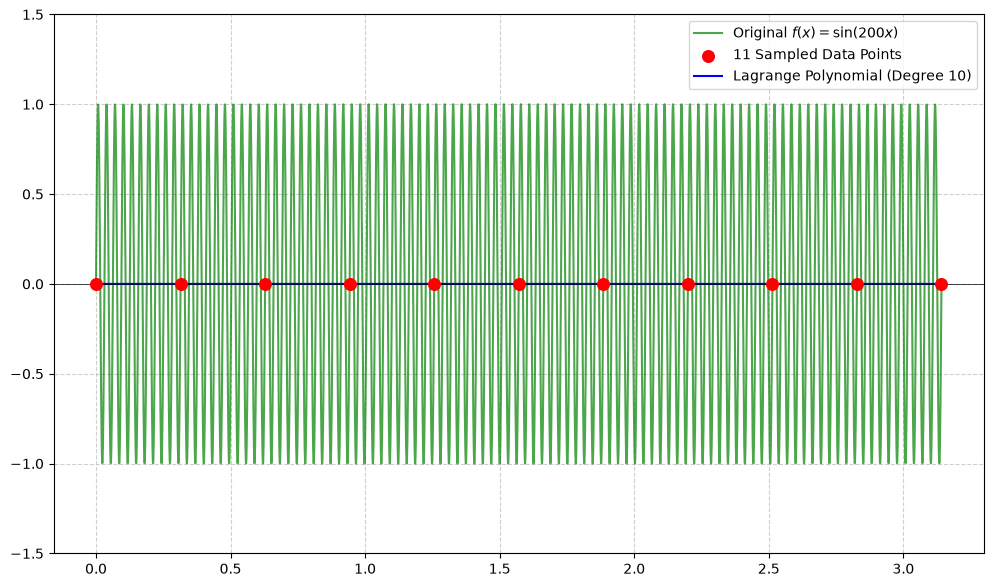

In [13]:
def f(x):
    return np.sin(200 * x)

x_nodes = np.linspace(0, np.pi, 11)
y_nodes = f(x_nodes)
x_dense = np.linspace(0, np.pi, 5000) 
y_dense = [lagrange_polynomial(x_nodes, y_nodes, x) for x in x_dense]

plt.figure(figsize=(12, 7))
plt.plot(x_dense, f(x_dense), label='Original $f(x) = \\sin(200x)$', color='green', alpha=0.7)
plt.scatter(x_nodes, y_nodes, color='red', s=70, zorder=5, label='11 Sampled Data Points')
plt.plot(x_dense, y_dense, label='Lagrange Polynomial (Degree 10)', color='blue', linestyle='-')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=0.5)
plt.ylim(-1.5, 1.5) 
plt.show()

8) Does it pass through all the point? Does it look like the original function?

It does pass through all the points, but it doesn't looks like the original function. We might need more data points, and there's concern of the degree being too high as well.

### Experiment: 200 times as many sample points

Use **2,200 equally spaced points** for $f(x) = \sin(200x)$, giving a Lagrange polynomial of degree at most 2,199. This uses the same `lagrange_polynomial` function from Part 6, evaluating the whole plotting array at once to reduce Python loop overhead.

More points do not guarantee better numerical results: such a high-degree polynomial on equally spaced nodes can be unstable, and the direct product formula may overflow. The output below reports non-finite values and values outside the displayed y-range.

Sample points: 2200; maximum degree: 2199
Non-finite interpolated values: 3980 / 5000
Finite values outside the plot limits: 1019


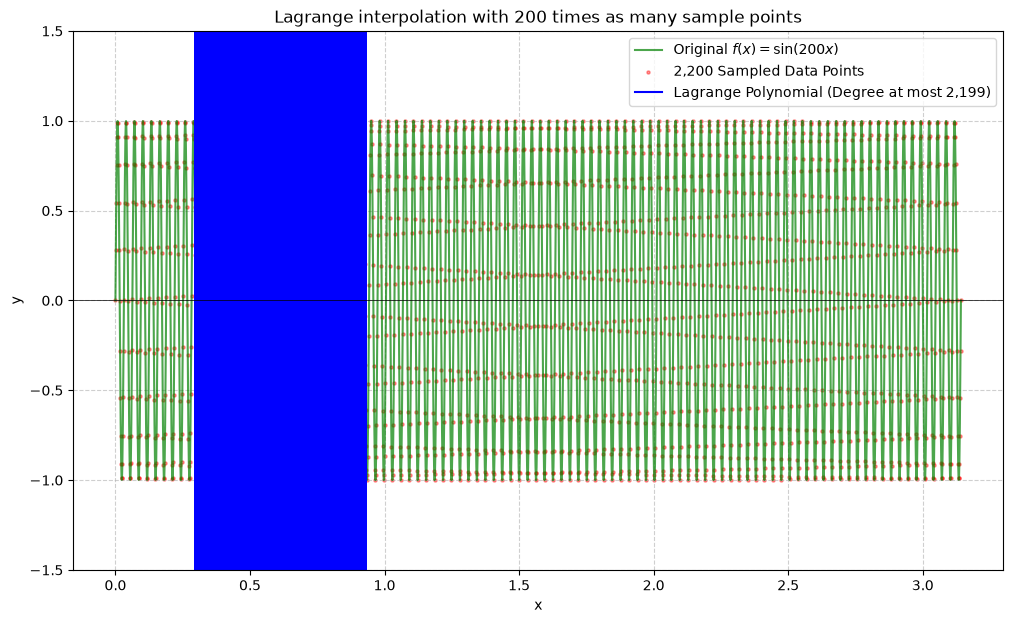

In [14]:
# Separate experiment: keep the original 11-point plots above.
num_points_more = 11 * 200
x_nodes_more = np.linspace(0, np.pi, num_points_more)
y_nodes_more = np.sin(200 * x_nodes_more)
x_dense_more = np.linspace(0, np.pi, 5000)

# The existing implementation accepts an array of evaluation points.
# Report numerical failures below instead of repeating overflow warnings.
with np.errstate(over='ignore', invalid='ignore', divide='ignore'):
    y_dense_more = lagrange_polynomial(
        x_nodes_more, y_nodes_more, x_dense_more
    )

finite_more = np.isfinite(y_dense_more)
print(f'Sample points: {num_points_more}; maximum degree: {num_points_more - 1}')
print(f'Non-finite interpolated values: {np.count_nonzero(~finite_more)} / {len(x_dense_more)}')
print(f'Finite values outside the plot limits: {np.count_nonzero(finite_more & (np.abs(y_dense_more) > 1.5))}')

plt.figure(figsize=(12, 7))
plt.plot(x_dense_more, np.sin(200 * x_dense_more),
         label=r'Original $f(x) = \sin(200x)$', color='green', alpha=0.7)
plt.scatter(x_nodes_more, y_nodes_more, color='red', s=5, alpha=0.4,
            label=f'{num_points_more:,} Sampled Data Points')
plt.plot(x_dense_more, y_dense_more, color='blue',
         label=f'Lagrange Polynomial (Degree at most {num_points_more - 1:,})')
plt.title('Lagrange interpolation with 200 times as many sample points')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=0.5)
plt.ylim(-1.5, 1.5)
plt.show()

### Why the previous plot breaks, and a stable comparison

The 2,200-point experiment above produced **3,980 non-finite values out of 5,000 evaluations**, plus **1,019 finite values outside the displayed range**. Matplotlib leaves gaps at non-finite values, while `ylim(-1.5, 1.5)` clips the huge finite values. This explains the missing curve and the rectangle-like appearance; it is numerical failure, not a trustworthy plot of the interpolating polynomial.

The direct Lagrange formula multiplies 2,199 factors per basis term. Intermediate products can overflow, and cancellation can destroy accuracy. High-degree interpolation on equally spaced nodes is also very ill-conditioned, so changing only the evaluation formula is insufficient.

Below is a **separate comparison**, still using 2,200 samples and a single Lagrange polynomial of degree at most 2,199. It uses **Chebyshev-Lobatto nodes** (clustered near the endpoints) and the **barycentric formula** with explicit weights. The nodes have changed, so this is a different interpolating polynomial from the equally spaced experiment above. See the [SciPy explanation and formulas](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.BarycentricInterpolator.html).

There are 100 oscillations of $sin(200x)$ over $[0,pi]$, which can look like a dense band even when plotted correctly. The second panel zooms into the first five oscillations. The printed error is measured on the plotting grid, not a rigorous bound over the entire interval.

Nodes: 2,200 (Chebyshev spacing); maximum degree: 2,199
Finite evaluations: 10001 / 10001
Maximum absolute error on the plotting grid: 1.193e-13


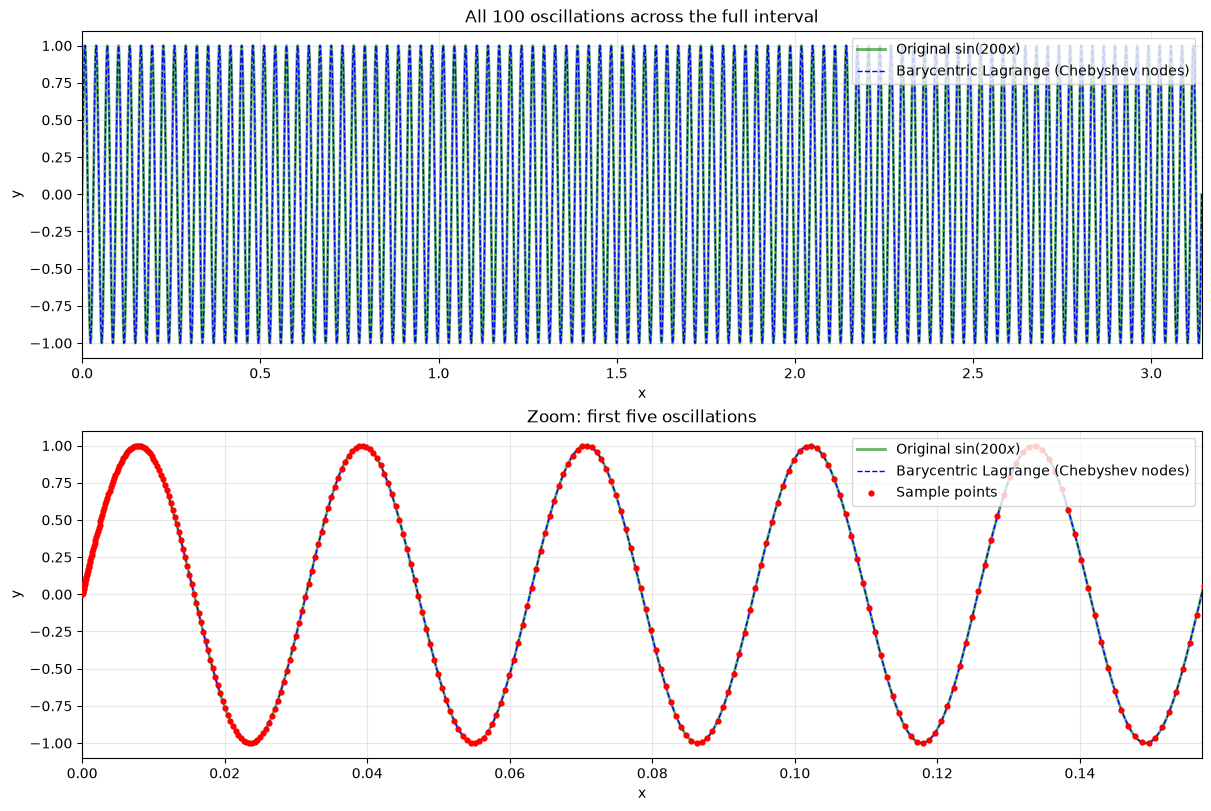

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BarycentricInterpolator

num_points_cheb = 11 * 200
indices_cheb = np.arange(num_points_cheb)
# Chebyshev-Lobatto nodes include both endpoints and cluster near them.
x_nodes_cheb = (np.pi / 2) * (
    1 - np.cos(np.pi * indices_cheb / (num_points_cheb - 1))
)
y_nodes_cheb = np.sin(200 * x_nodes_cheb)

# Explicit weights avoid computing thousands of long products.
weights_cheb = (-1.0) ** indices_cheb
weights_cheb[[0, -1]] *= 0.5
polynomial_cheb = BarycentricInterpolator(
    x_nodes_cheb, y_nodes_cheb, wi=weights_cheb
)
x_plot_cheb = np.linspace(0, np.pi, 10001)
y_plot_cheb = polynomial_cheb(x_plot_cheb)
error_cheb = np.abs(y_plot_cheb - np.sin(200 * x_plot_cheb))

print(f'Nodes: {num_points_cheb:,} (Chebyshev spacing); maximum degree: {num_points_cheb - 1:,}')
print(f'Finite evaluations: {np.count_nonzero(np.isfinite(y_plot_cheb))} / {len(x_plot_cheb)}')
print(f'Maximum absolute error on the plotting grid: {np.max(error_cheb):.3e}')

fig_cheb, axes_cheb = plt.subplots(2, 1, figsize=(12, 8), layout='constrained')
for ax_cheb in axes_cheb:
    ax_cheb.plot(x_plot_cheb, np.sin(200 * x_plot_cheb),
                 color='green', linewidth=2, alpha=0.6, label=r'Original $\sin(200x)$')
    ax_cheb.plot(x_plot_cheb, y_plot_cheb, color='blue', linestyle='--',
                 linewidth=1, label='Barycentric Lagrange (Chebyshev nodes)')
    ax_cheb.set(xlabel='x', ylabel='y')
    ax_cheb.grid(True, alpha=0.3)
    ax_cheb.legend(loc='upper right')
axes_cheb[0].set(xlim=(0, np.pi), title='All 100 oscillations across the full interval')
axes_cheb[1].scatter(x_nodes_cheb, y_nodes_cheb, color='red', s=12,
                     zorder=3, label='Sample points')
axes_cheb[1].set(xlim=(0, np.pi / 20), title='Zoom: first five oscillations')
axes_cheb[1].legend(loc='upper right')
plt.show()